# Домашнее задание 5

## Выбросы и кодирование категориальных признаков

# 1. Загрузка данных и обработка пропусков

Загрузим `loan_prediction_dataset.csv` и заполним пропуски теми же правилами, которые использовались в ДЗ 4:

- `LoanAmount` и `Loan_Amount_Term` медианой;
- категориальные признаки и `Credit_History` модой.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("loan_prediction_dataset.csv")

numeric_for_median = [
    "LoanAmount",
    "Loan_Amount_Term"
]

categorical_for_mode = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Credit_History"
]

for column in numeric_for_median:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_for_mode:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Количество пропусков:", df.isna().sum().sum())
print("Размер датасета:", df.shape)

Количество пропусков: 0
Размер датасета: (614, 13)


# 2. Поиск выбросов методом IQR

IQR — межквартильный размах:

`IQR = Q3 - Q1`

Наблюдение считается выбросом, если оно находится:

- ниже `Q1 - 1.5 × IQR`;
- выше `Q3 + 1.5 × IQR`.

Проверим таким способом `ApplicantIncome` и `LoanAmount`.

In [2]:
def find_iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print("Признак:", column)
    print("Нижняя граница:", round(lower, 2))
    print("Верхняя граница:", round(upper, 2))
    print("Количество выбросов:", len(outliers))

    return outliers

In [3]:
income_iqr = find_iqr_outliers(df, "ApplicantIncome")

income_iqr[["Loan_ID", "ApplicantIncome"]]

Признак: ApplicantIncome
Нижняя граница: -1498.75
Верхняя граница: 10171.25
Количество выбросов: 50


,Loan_ID,ApplicantIncome
9,LP001020,12841
34,LP001100,12500
54,LP001186,11500
67,LP001233,10750
102,LP001350,13650
106,LP001369,11417
115,LP001401,14583
119,LP001422,10408
126,LP001448,23803
128,LP001451,10513


In [4]:
loan_iqr = find_iqr_outliers(df, "LoanAmount")

loan_iqr[["Loan_ID", "LoanAmount"]]

Признак: LoanAmount
Нижняя граница: 3.5
Верхняя граница: 261.5
Количество выбросов: 41


,Loan_ID,LoanAmount
5,LP001011,267.0
9,LP001020,349.0
21,LP001046,315.0
34,LP001100,320.0
54,LP001186,286.0
67,LP001233,312.0
83,LP001273,265.0
126,LP001448,370.0
130,LP001469,650.0
135,LP001488,290.0


# 3. Поиск выбросов методом стандартного отклонения

Для второго метода используем правило **трёх стандартных отклонений**.

Границы рассчитываются как:

`среднее ± 3 × стандартное отклонение`

Значения за пределами этих границ считаются выбросами.

In [5]:
def find_std_outliers(data, column):
    mean = data[column].mean()
    std = data[column].std()

    lower = mean - 3 * std
    upper = mean + 3 * std

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print("Признак:", column)
    print("Нижняя граница:", round(lower, 2))
    print("Верхняя граница:", round(upper, 2))
    print("Количество выбросов:", len(outliers))

    return outliers

In [6]:
income_std = find_std_outliers(df, "ApplicantIncome")

income_std[["Loan_ID", "ApplicantIncome"]]

Признак: ApplicantIncome
Нижняя граница: -12923.67
Верхняя граница: 23730.58
Количество выбросов: 8


,Loan_ID,ApplicantIncome
126,LP001448,23803
155,LP001536,39999
171,LP001585,51763
183,LP001637,33846
185,LP001640,39147
333,LP002101,63337
409,LP002317,81000
443,LP002422,37719


In [7]:
loan_std = find_std_outliers(df, "LoanAmount")

loan_std[["Loan_ID", "LoanAmount"]]

Признак: LoanAmount
Нижняя граница: -106.57
Верхняя граница: 398.07
Количество выбросов: 15


,Loan_ID,LoanAmount
130,LP001469,650.0
155,LP001536,600.0
171,LP001585,700.0
177,LP001610,495.0
278,LP001907,436.0
308,LP001996,480.0
333,LP002101,490.0
369,LP002191,570.0
432,LP002386,405.0
487,LP002547,500.0


# 4. Сравнение результатов двух методов

Сравним индексы строк, которые были признаны выбросами.

Для каждого признака найдём:

- наблюдения, найденные обоими методами;
- наблюдения, найденные только IQR;
- наблюдения, найденные только методом стандартного отклонения.

In [8]:
def compare_outliers(iqr_outliers, std_outliers):
    iqr_indexes = set(iqr_outliers.index)
    std_indexes = set(std_outliers.index)

    common = iqr_indexes & std_indexes
    only_iqr = iqr_indexes - std_indexes
    only_std = std_indexes - iqr_indexes

    print("Найдены обоими методами:", len(common))
    print("Только IQR:", len(only_iqr))
    print("Только std:", len(only_std))

    print("\nОбщие индексы:")
    print(sorted(common))

    print("\nТолько IQR:")
    print(sorted(only_iqr))

    print("\nТолько std:")
    print(sorted(only_std))

    return common, only_iqr, only_std

In [9]:
print("ApplicantIncome")
income_common, income_only_iqr, income_only_std = compare_outliers(
    income_iqr,
    income_std
)

ApplicantIncome
Найдены обоими методами: 8
Только IQR: 42
Только std: 0

Общие индексы:
[126, 155, 171, 183, 185, 333, 409, 443]

Только IQR:
[9, 34, 54, 67, 102, 106, 115, 119, 128, 130, 138, 144, 146, 191, 199, 254, 258, 271, 278, 284, 308, 324, 369, 370, 424, 432, 438, 467, 475, 478, 483, 487, 493, 506, 509, 525, 533, 534, 561, 572, 594, 604]

Только std:
[]


In [10]:
print("LoanAmount")
loan_common, loan_only_iqr, loan_only_std = compare_outliers(
    loan_iqr,
    loan_std
)

LoanAmount
Найдены обоими методами: 15
Только IQR: 26
Только std: 0

Общие индексы:
[130, 155, 171, 177, 278, 308, 333, 369, 432, 487, 506, 523, 525, 561, 604]

Только IQR:
[5, 9, 21, 34, 54, 67, 83, 126, 135, 161, 233, 253, 258, 260, 324, 325, 351, 372, 381, 391, 409, 514, 536, 572, 592, 600]

Только std:
[]


Методы находят не полностью одинаковые наборы наблюдений.

IQR-правило обычно обнаруживает больше выбросов в этих признаках. Оно основано на квартилях и поэтому устойчиво к очень большим значениям.

Метод трёх стандартных отклонений использует среднее и стандартное отклонение. `ApplicantIncome` и `LoanAmount` имеют правостороннее распределение: есть небольшое количество очень больших значений. Такие значения увеличивают среднее и стандартное отклонение, из-за чего граница метода `std` становится более широкой.

Поэтому самые экстремальные значения определяются обоими методами, а менее экстремальные высокие значения могут определяться только IQR-правилом.

# 5. Визуальная проверка выбросов

Построим boxplot и гистограммы для `ApplicantIncome` и `LoanAmount`.

Точки, расположенные далеко за основной частью boxplot, визуально подтверждают наличие необычно больших значений.

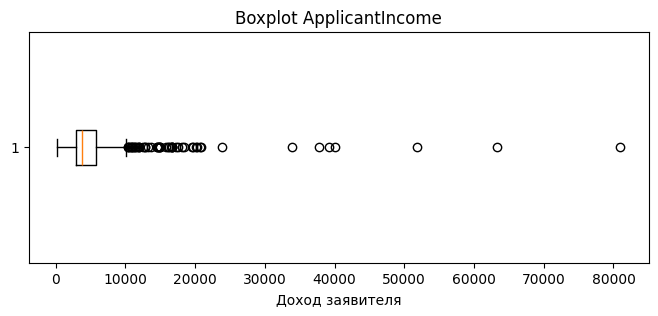

In [11]:
plt.figure(figsize=(8, 3))
plt.boxplot(df["ApplicantIncome"], vert=False)
plt.title("Boxplot ApplicantIncome")
plt.xlabel("Доход заявителя")
plt.show()

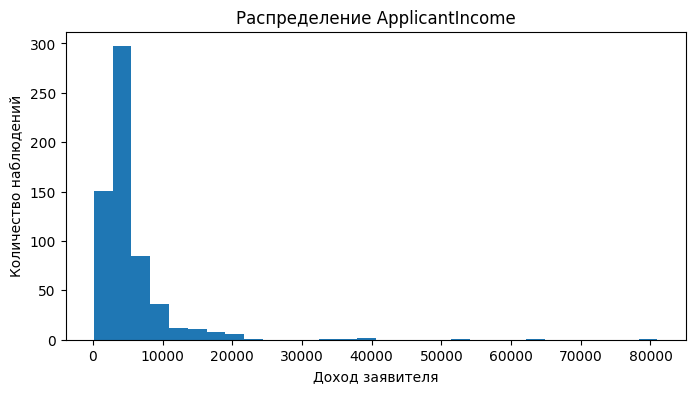

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(df["ApplicantIncome"], bins=30)
plt.title("Распределение ApplicantIncome")
plt.xlabel("Доход заявителя")
plt.ylabel("Количество наблюдений")
plt.show()

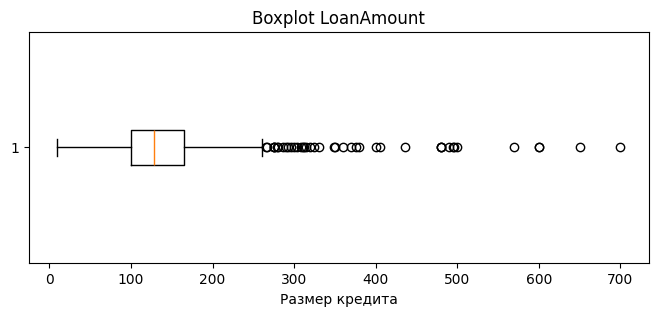

In [13]:
plt.figure(figsize=(8, 3))
plt.boxplot(df["LoanAmount"], vert=False)
plt.title("Boxplot LoanAmount")
plt.xlabel("Размер кредита")
plt.show()

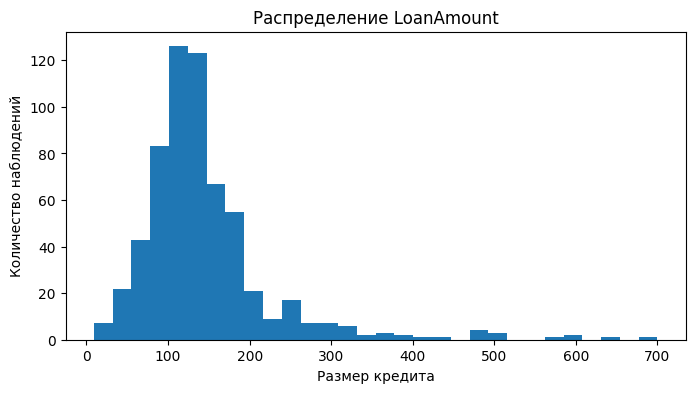

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(df["LoanAmount"], bins=30)
plt.title("Распределение LoanAmount")
plt.xlabel("Размер кредита")
plt.ylabel("Количество наблюдений")
plt.show()

В этой работе выбросы оставим без удаления и замены.

Причины:

1. Большой доход или большой размер кредита не обязательно являются ошибкой в данных. Это могут быть реальные клиенты с высоким доходом и крупными кредитами.
2. Датасет относительно небольшой, поэтому удаление большого количества строк приведёт к дополнительной потере информации.

# Варианты кодирования категориальных признаков

Категориальные данные необходимо преобразовать в числовой формат перед использованием во многих алгоритмах машинного обучения.

Возможные способы:

- **Binary encoding / mapping** — удобно для признаков с двумя вариантами (`Yes/No`, `Male/Female`).
- **Ordinal encoding** — подходит, если категории имеют естественный порядок.
- **One-Hot Encoding** — создаёт отдельный столбец для каждой категории и подходит для номинальных признаков, где порядка нет.

Выберем следующие правила:

- `Gender`: Male → 0, Female → 1;
- `Married`: No → 0, Yes → 1;
- `Education`: Not Graduate → 0, Graduate → 1;
- `Self_Employed`: No → 0, Yes → 1;
- `Loan_Status`: N → 0, Y → 1;
- `Dependents`: 0 → 0, 1 → 1, 2 → 2, 3+ → 3, потому что категории имеют естественный порядок;
- `Property_Area`: One-Hot Encoding, поскольку Urban, Rural и Semiurban не имеют естественного порядка;
- `Loan_ID` удалим, поскольку это идентификатор, а не содержательный признак;
- `Credit_History` уже представлена числами 0 и 1, поэтому дополнительное кодирование не требуется.

# 8. Применение кодирования

Создадим отдельную копию датасета, чтобы сохранить исходные очищенные данные.

In [15]:
df_encoded = df.copy()

df_encoded = df_encoded.drop(columns=["Loan_ID"])

df_encoded["Gender"] = df_encoded["Gender"].map({
    "Male": 0,
    "Female": 1
})

df_encoded["Married"] = df_encoded["Married"].map({
    "No": 0,
    "Yes": 1
})

df_encoded["Education"] = df_encoded["Education"].map({
    "Not Graduate": 0,
    "Graduate": 1
})

df_encoded["Self_Employed"] = df_encoded["Self_Employed"].map({
    "No": 0,
    "Yes": 1
})

df_encoded["Loan_Status"] = df_encoded["Loan_Status"].map({
    "N": 0,
    "Y": 1
})

df_encoded["Dependents"] = df_encoded["Dependents"].replace({
    "0": 0,
    "1": 1,
    "2": 2,
    "3+": 3
}).astype(int)

df_encoded = pd.get_dummies(
    df_encoded,
    columns=["Property_Area"],
    dtype=int
)

df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,0,1
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,1
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0,0,1
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,0,1


Проверка:

In [16]:
print("Размер исходного очищенного датасета:", df.shape)
print("Размер после кодирования:", df_encoded.shape)

print("\nКоличество пропусков:")
print(df_encoded.isna().sum().sum())

print("\nКоличество object-столбцов:")
print(len(df_encoded.select_dtypes(include="object").columns))

print("\nТипы данных:")
print(df_encoded.dtypes)

Размер исходного очищенного датасета: (614, 13)
Размер после кодирования: (614, 14)

Количество пропусков:
0

Количество object-столбцов:
0

Типы данных:
Gender                       int64
Married                      int64
Dependents                   int32
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int64
Property_Area_Rural          int32
Property_Area_Semiurban      int32
Property_Area_Urban          int32
dtype: object


In [17]:
df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,0,1
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,1
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0,0,1
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,0,1


После кодирования:

- количество строк не изменилось;
- `Loan_ID` удалён;
- остальные категориальные признаки преобразованы в числа;
- пропусков нет;
- текстовых признаков, которые могут мешать дальнейшему машинному обучению, не осталось.